# TP7 — Classification MNIST avec CNN
**Dataset :** MNIST (chiffres 0-9, intégré dans PyTorch)

Tous les TODO du prof sont complétés.

In [ ]:
# ============================================================
# CELLULE 1 — Imports
# ============================================================
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [ ]:
# ============================================================
# CELLULE 2 — Chargement du dataset MNIST (intégré dans PyTorch)
# Pas besoin de Google Drive — PyTorch le télécharge automatiquement
# ============================================================

batch_size_train = 64
batch_size_test  = 1000

# Train loader : 60 000 images, mélangées, par paquets de 64
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        '/files/',
        train=True,
        download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.1307,), (0.3081,))
        ])
    ),
    batch_size=batch_size_train,
    shuffle=True
)

# Test loader : 10 000 images
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        '/files/',
        train=False,
        download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.1307,), (0.3081,))
        ])
    ),
    batch_size=batch_size_test,
    shuffle=True
)

print('Train :', len(train_loader.dataset), 'images')
print('Test  :', len(test_loader.dataset),  'images')
print('Classes : chiffres 0 à 9')

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.1MB/s]

Train : 60000 images
Test  : 10000 images
Classes : chiffres 0 à 9


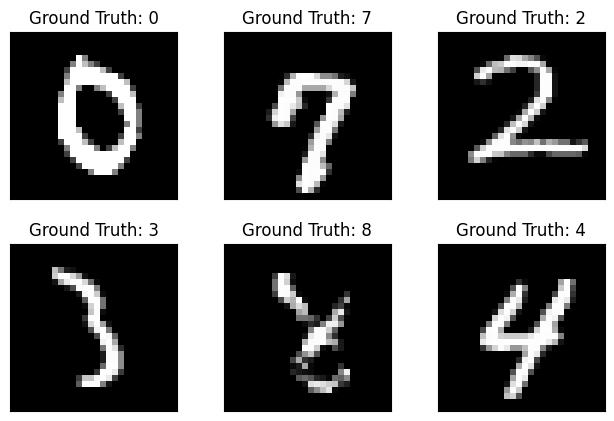

In [ ]:
# ============================================================
# CELLULE 3 — Visualisation de quelques images
# ============================================================
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title('Ground Truth: {}'.format(example_targets[i]))
    plt.xticks([])
    plt.yticks([])
plt.show()

## Définition du réseau CNN

On définit une classe `Net` héritant de `nn.Module`.
Le constructeur `__init__` déclare toutes les couches.
La méthode `forward` décrit comment les données traversent le réseau.

**TODO complétés :**
1. Conv valide kernel 5 — 1 → 10 canaux
2. MaxPool 2×2
3. ReLU
4. Conv valide kernel 5 — 10 → 20 canaux
5. Dropout2D
6. MaxPool 2×2
7. ReLU
8. Flatten
9. FC → 50
10. ReLU
11. FC 50 → 10
12. LogSoftmax

In [ ]:
# ============================================================
# CELLULE 4 — Définition du réseau CNN (TODO complétés)
# ============================================================

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

      
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)

      
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)

        self.conv2_drop = nn.Dropout2d()

      
        self.fc1 = nn.Linear(320, 50)

      
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):

        # --- BLOC 1 ---
        # convolution valide kernel 5  (28x28 -> 24x24)
        x = self.conv1(x)
        # TODO 2 : max pooling 2x2  (24x24 -> 12x12)
        x = F.max_pool2d(x, 2)
        # TODO 3 : ReLU
        x = F.relu(x)

        # --- BLOC 2 ---
        #  convolution valide kernel 5  (12x12 -> 8x8)
        x = self.conv2(x)
        # TODO 5 : Dropout 2D
        x = self.conv2_drop(x)
        # TODO 6 : max pooling 2x2  (8x8 -> 4x4)
        x = F.max_pool2d(x, 2)
        # TODO 7 : ReLU
        x = F.relu(x)

        #  Flatten — 20 canaux x 4x4 = 320 valeurs
        x = x.view(-1, 320)

        x = self.fc1(x)
        x = F.relu(x)

        # Dropout sur la couche FC aussi
        x = F.dropout(x, training=self.training)

        # TODO 11 : FC2 -> 10 classes
        x = self.fc2(x)

        # TODO 12 : LogSoftmax — compatible avec nll_loss
        return F.log_softmax(x, dim=1)

In [ ]:
# ============================================================
# CELLULE 5 — Initialisation He des poids
# ============================================================

# He initialization : adapté aux activations ReLU
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_uniform_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)

In [ ]:
# ============================================================
# CELLULE 6 — Création du modèle et optimiseur
# ============================================================

# GPU si disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

# Création du modèle
model = Net()
model.apply(weights_init)
model = model.to(device)

print('Paramètres :', sum(p.numel() for p in model.parameters() if p.requires_grad))

# Optimiseur SGD 
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

Device : cuda
Paramètres : 21840


In [ ]:
# ============================================================
# CELLULE 7 — Fonction d'entraînement
# ============================================================

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data),
                len(train_loader.dataset), loss.item()))

In [ ]:
# ============================================================
# CELLULE 8 — Fonction de test
# ============================================================

def test():
    model.eval()
    test_loss = 0
    correct   = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
    test_loss /= len(test_loader.dataset)
    print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [ ]:
# ============================================================
# CELLULE 9 — Lancement de l'entraînement
# ============================================================

# Performance avant entraînement
test()

# Entraînement sur 3 epochs 
n_epochs = 3
for epoch in range(1, n_epochs + 1):
    train(epoch)
    test()


Test set: Avg. loss: 2.4312, Accuracy: 721/10000 (7%)

Train Epoch: 1 [0/60000]	Loss: 2.743773
Train Epoch: 1 [640/60000]	Loss: 2.357866
Train Epoch: 1 [1280/60000]	Loss: 2.315782
Train Epoch: 1 [1920/60000]	Loss: 2.229172
Train Epoch: 1 [2560/60000]	Loss: 2.043684
Train Epoch: 1 [3200/60000]	Loss: 2.141693
Train Epoch: 1 [3840/60000]	Loss: 2.177562
Train Epoch: 1 [4480/60000]	Loss: 2.073809
Train Epoch: 1 [5120/60000]	Loss: 2.277789
Train Epoch: 1 [5760/60000]	Loss: 1.923816
Train Epoch: 1 [6400/60000]	Loss: 1.911744
Train Epoch: 1 [7040/60000]	Loss: 1.852502
Train Epoch: 1 [7680/60000]	Loss: 1.897117
Train Epoch: 1 [8320/60000]	Loss: 1.741620
Train Epoch: 1 [8960/60000]	Loss: 1.517650
Train Epoch: 1 [9600/60000]	Loss: 1.289278
Train Epoch: 1 [10240/60000]	Loss: 1.628488
Train Epoch: 1 [10880/60000]	Loss: 1.412057
Train Epoch: 1 [11520/60000]	Loss: 1.485532
Train Epoch: 1 [12160/60000]	Loss: 1.351518
Train Epoch: 1 [12800/60000]	Loss: 1.427653
Train Epoch: 1 [13440/60000]	Loss: 1.469

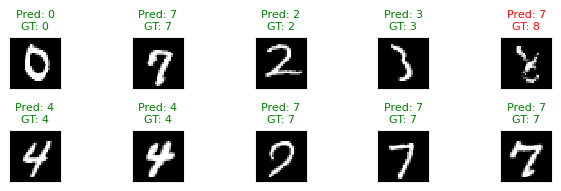

In [ ]:
# ============================================================
# CELLULE 10 — Visualisation des prédictions
# ============================================================

model.eval()
output = model(example_data.to(device))

fig = plt.figure()
for i in range(10):
    plt.subplot(5, 5, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0].cpu(), cmap='gray', interpolation='none')
    pred  = output.data.max(1, keepdim=True)[1][i].item()
    truth = example_targets[i].item()
    color = 'green' if pred == truth else 'red'
    plt.title('Pred: {}\nGT: {}'.format(pred, truth),
              fontsize=8, color=color)
    plt.xticks([])
    plt.yticks([])
plt.show()